# ■ 딥러닝 컴페티션

### 컴페티션의 목표는 ① 학습 평가의 이해, ② 딥러닝 성능 개선 방법 숙지, ③ 설명력을 키우는게 목적

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X (상대평가는 안하지만, 개인 성능은 valid score가 75이상 나오길 권장함.)

※ 수업 코드 사용 가능

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. ① 코딩의 인과성, ② 설명의 깊이만 충분하다면, 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 모델 선택, 튜닝 기준 (650자 이내, 주석 서술하기)

4. (25점) 개선사항 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

</br>

## ■ 깃허브 정리 (10점)

1. 포트폴리오로 쓸 수 있도록 프로젝트 제목, 전처리, EDA, 모델링 방법, 성능 결과를 캡처 이미지와 함께 잘 정리.

</br>

## ■ 제출방법

5월 12일 23시 59분까지, 오승환 강사에게 DM으로 ipynb 파일 제출, 이후 깃허브 링크도 정리되는대로 DM 제출

# 1. 원본 데이터 출처

https://www.kaggle.com/datasets/parisrohan/credit-score-classification

# 2. 데이터 클리닝 방법 출처:

https://www.kaggle.com/code/clkmuhammed/credit-score-classification-part-1-data-cleaning#Download-Link

In [26]:
!pip install tab-transformer-pytorch

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import RobustScaler
from torch.utils.data import TensorDataset, DataLoader
from tab_transformer_pytorch import TabTransformer
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tqdm import tqdm

df = pd.read_csv('/content/train2.csv')

In [28]:
df.info()
# 해당 데이터는 100,000개의 데이터이다.
# 'Payment_of_Min_Amount'의 결과 중 'NM'은 기재되지 않은 것을 의미하는데 이를 정보 누락 자체에서도 유의미한 패턴을 찾기 위해 결측치로 처리하지 않음

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  int64  
 5   SSN                       100000 non-null  int64  
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  int64  
 13  Type_of_Loan              100000 non-null  ob

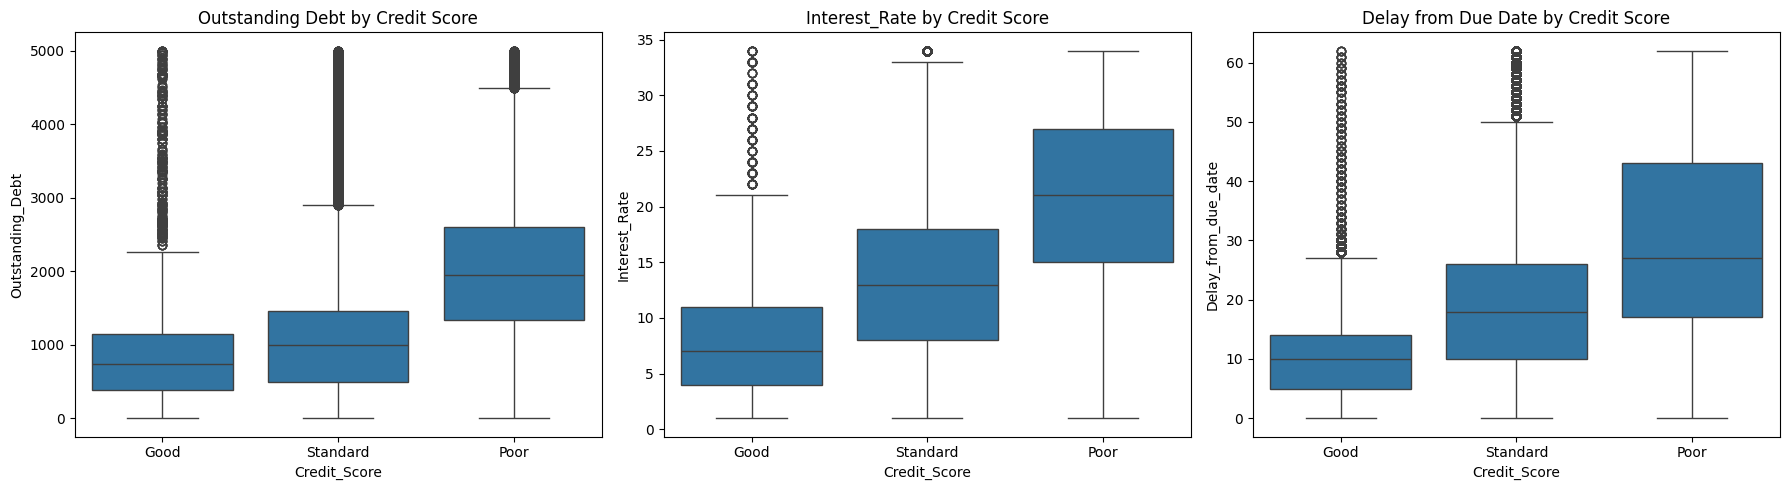

In [29]:
# 재무 위험도를 나타내는 피처들과 신용 등급 간 비교


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. 미지급 잔액에 따른 신용 등급
sns.boxplot(ax=axes[0], data=df, x='Credit_Score', y='Outstanding_Debt')
axes[0].set_title('Outstanding Debt by Credit Score')

# 2. 연체 일수에 따른 신용 등급
sns.boxplot(ax=axes[2], data=df, x='Credit_Score', y='Delay_from_due_date')
axes[2].set_title('Delay from Due Date by Credit Score')

# 3. 적용 이자율에 따른 신용 등급
sns.boxplot(ax=axes[1], data=df, x='Credit_Score', y='Interest_Rate')
axes[1].set_title('Interest_Rate by Credit Score')

plt.tight_layout()
plt.show()

In [30]:
print("1. 신용 등급별 미지급 잔액(Outstanding_Debt) 평균")
print(df.groupby('Credit_Score')['Outstanding_Debt'].mean().round(2))
print("-" * 50)

print("2. 신용 등급별 평균 연체 일수(Delay_from_due_date) 평균")
print(df.groupby('Credit_Score')['Delay_from_due_date'].mean().round(2))
print("-" * 50)

print("3. 신용 등급별 적용 이자율(Interest_Rate) 평균")
print(df.groupby('Credit_Score')['Interest_Rate'].mean().round(2))
print("-" * 50)

1. 신용 등급별 미지급 잔액(Outstanding_Debt) 평균
Credit_Score
Good         801.26
Poor        2081.47
Standard    1278.42
Name: Outstanding_Debt, dtype: float64
--------------------------------------------------
2. 신용 등급별 평균 연체 일수(Delay_from_due_date) 평균
Credit_Score
Good        10.96
Poor        29.73
Standard    19.76
Name: Delay_from_due_date, dtype: float64
--------------------------------------------------
3. 신용 등급별 적용 이자율(Interest_Rate) 평균
Credit_Score
Good         7.66
Poor        20.19
Standard    13.75
Name: Interest_Rate, dtype: float64
--------------------------------------------------


위의 그래프를 통해


*   신용 등급이 낮을수록 미지급 잔액이 높아짐 (평균 : Good 대비 Poor가 약 2.5배)
*   신용 등급이 낮을수록 연체 일수가 늘어남 (평균 : Good 대비 Poor가 약 2.9배)
*   신용 등급이 낮을수록 적용 이자율이 높아짐 (평균 : Good 대비 Poor가 약 2.9배)


해당 결과를 볼 수 있다.

이는 모델이 각 클래스를 구분할 때 부채 규모와 연체 성향이 가장 강력한 판별 기준으로 작용할 것임이라 생각을 하였고 'Credit_Score'를 타겟변수 y로 설정하였다.

In [31]:
# 1. 데이터 전처리

# 1-1. 컬럼 삭제

# 해당 데이터 중 필요없는 컬럼은 'ID', 'Customer_ID', 'Name', 'SSN', 'Month'이라 판단하였고
# 'Age'컬럼의 경우 나이대별 대출 상환능력 등 신용점수를 측정할 때 필요한 컬럼이라고 판단

# 'Type_of_Loan' 컬럼의 경우 개인이 받은 대출의 종류를 나타내는데 이를 라밸인코딩하면 'Num_of_Loan'과 겹쳐 다중공선성 문제가 발생할 수 있어서 해당 컬럼도 제외

drop_cols = ['ID', 'Customer_ID', 'Name', 'SSN', 'Month', 'Type_of_Loan']
df = df.drop(columns=drop_cols)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Age                       100000 non-null  int64  
 1   Occupation                100000 non-null  object 
 2   Annual_Income             100000 non-null  float64
 3   Monthly_Inhand_Salary     100000 non-null  float64
 4   Num_Bank_Accounts         100000 non-null  int64  
 5   Num_Credit_Card           100000 non-null  int64  
 6   Interest_Rate             100000 non-null  int64  
 7   Num_of_Loan               100000 non-null  int64  
 8   Delay_from_due_date       100000 non-null  int64  
 9   Num_of_Delayed_Payment    100000 non-null  int64  
 10  Changed_Credit_Limit      100000 non-null  float64
 11  Num_Credit_Inquiries      100000 non-null  int64  
 12  Credit_Mix                100000 non-null  object 
 13  Outstanding_Debt          100000 non-null  fl

In [33]:
# 1-2. 라밸 인코딩

# 데이터타입이 object인 컬럼('Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour')을 범주형 변수로 인코딩
label_encoders = {}
for col in ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour', 'Credit_Score']:
    label_encoders[col] = LabelEncoder()
    df[col] = label_encoders[col].fit_transform(df[col])

In [34]:
label_encoders

{'Occupation': LabelEncoder(),
 'Credit_Mix': LabelEncoder(),
 'Payment_of_Min_Amount': LabelEncoder(),
 'Payment_Behaviour': LabelEncoder(),
 'Credit_Score': LabelEncoder()}

In [35]:
# 1-3. 파생변수 생성

# 조금 더 높은 성능을 도출하기 위해 파생변수를 생성


# a. 총부채상환비율
df['Debt_to_Income_Ratio'] = df['Outstanding_Debt'] / (df['Annual_Income'] + 1e-5)

# b. 월급 대비 월 할부금 부담률
# (개인의 체감적인 재정 부담)
df['EMI_to_Salary_Ratio'] = df['Total_EMI_per_month'] / (df['Monthly_Inhand_Salary'] + 1e-5)

# c. 실질 가용 월 잔고
# (월급에서 대출 할부금과 투자금을 모두 제외하고 실제로 쓸 수 있는 여유 자금)
df['Net_Available_Balance'] = df['Monthly_Inhand_Salary'] - df['Total_EMI_per_month'] - df['Amount_invested_monthly']

# d. 소득 대비 부채 비율 (DTI)
# (분모가 0이 되는 것을 방지하기 위해 1e-6을 더해줌)
df['Debt_to_Income_Ratio'] = df['Outstanding_Debt'] / (df['Annual_Income'] + 1e-6)

# e. 월 소득 대비 할부/대출금 지출 비율
df['EMI_to_Income_Ratio'] = df['Total_EMI_per_month'] / (df['Monthly_Inhand_Salary'] + 1e-6)

# f. 총 금융 계좌/대출 수 (규모)
# (결측치가 있을 경우 0으로 채우고 더함)
df['Total_Financial_Accounts'] = df['Num_Bank_Accounts'].fillna(0) + \
                                 df['Num_Credit_Card'].fillna(0) + \
                                 df['Num_of_Loan'].fillna(0)

# g. 여유 자금 비율
df['Balance_to_Salary_Ratio'] = df['Monthly_Balance'] / (df['Monthly_Inhand_Salary'] + 1e-6)

# h. 고위험군 플래그 (Binary Flag)
# (연체 30일 이상 & 카드 대금 최소 지불(Yes)인 경우 1, 아니면 0)
# condition_high_risk = (df['Delay_from_due_date'] >= 30) & (df['Payment_of_Min_Amount'] == 'Yes')
# df['High_Risk_Flag'] = np.where(condition_high_risk, 1, 0) # 해당 컬럼은 모두 동일한 값을 가지므로 활용x

# i. 실질 잉여 현금 (Net Disposable Income)
# (투자금이 결측치일 경우 0으로 간주하여 계산)
df['Net_Disposable_Income'] = df['Monthly_Inhand_Salary'] - df['Total_EMI_per_month'] - df['Amount_invested_monthly'].fillna(0)

# j. 연체 심각도 지수 (Delay Severity Index)
df['Delay_Severity_Index'] = df['Delay_from_due_date'] * df['Num_of_Delayed_Payment']

# k. 건당 평균 부채 규모 (Average Debt per Loan)
# (대출 건수가 0인 경우를 대비해 분모에 1을 더해줌)
df['Average_Debt_per_Loan'] = df['Outstanding_Debt'] / (df['Num_of_Loan'].fillna(0) + 1)

# l. 나이 대비 부채 비율 (Debt to Age Ratio)
df['Debt_to_Age_Ratio'] = df['Outstanding_Debt'] / (df['Age'] + 1e-6)

# m. 신용 탐색 지표 (과도한 신용 조회 여부 Flag)
# (신용 조회 횟수가 5번을 초과하는 경우를 위험군(1)으로 설정)
df['High_Credit_Inquiry_Flag'] = (df['Num_Credit_Inquiries'] > 5).astype(int)

In [36]:
# 1-4. 타겟 변수 설정

X = df.drop('Credit_Score', axis=1)
y = df['Credit_Score']

In [37]:
# 1-5. train, test 분리

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [38]:
# 1-6. 연속형 변수만 정규화 적용

cat_cols = ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
cont_cols = [col for col in X.columns if col not in cat_cols]

categories_counts = tuple([len(label_encoders[col].classes_) for col in cat_cols])

In [39]:
# 1-7. 정규화

scaler = RobustScaler()
X_train_cont_scaled = scaler.fit_transform(X_train[cont_cols].values)
X_test_cont_scaled = scaler.transform(X_test[cont_cols].values)

In [40]:
# 2. PyTorch 텐서 및 DataLoader 구성


# 2-1. 범주형을 categ, 연속형을 cont로 따로 구분해서 tensor 도출

X_train_categ = torch.tensor(X_train[cat_cols].values, dtype=torch.int64)
X_test_categ = torch.tensor(X_test[cat_cols].values, dtype=torch.int64)
X_train_cont = torch.tensor(X_train_cont_scaled, dtype=torch.float32)
X_test_cont = torch.tensor(X_test_cont_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

In [41]:
# 2-2. Dataset 및 DataLoader 생성

batch_size = 1024

train_dataset = TensorDataset(X_train_categ, X_train_cont, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(X_test_categ, X_test_cont, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [42]:
# 3. 모델 정의


# 3-1. 디바이스 설정

device = torch.device('mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu'))
print(f"Using device: {device}")

Using device: cuda


In [43]:
# 3-2. TabTransformer 모델 정의


model = TabTransformer( # 해당 컴페티션의 정형 데이터에 최적화된 TabTransformer를 선택
    categories=categories_counts,
    num_continuous=len(cont_cols),
    dim=32,  # 64, 128을 해본 결과 괴적합 가능성이 있어 위험하기도 하고 dim=32일 때 val_acc가 가장 높아 32를 사용
    dim_out=len(label_encoders['Credit_Score'].classes_),
    depth=6, # 4는 얕아 금융데이터의 복잡한 상관관계를 못잡고 6일 때 val_acc가 가장 높아 32를 사용
    heads=8,
    attn_dropout=0.1,
    ff_dropout=0.1,
    mlp_hidden_mults=(4, 2),
    mlp_act=nn.ReLU(),
).to(device)

In [44]:
# 3-3. 모델 학습 준비
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.003) # Adam으로 했을 때 대비 0.1%p정도 더 높아지는 것을 확인 (유의미하지는 않지만 최대한 acc를 높이기 위해 사용)

# 검증 성능이 정체되면 학습률을 절반(0.5)으로 줄이는 스케줄러
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

In [45]:
# 4. 미니배치 학습 루프 (Early Stopping & Best Model 셋업)
num_epochs = 200
best_acc = 0.0
patience_counter = 0
early_stop_patience = 20

for epoch in range(num_epochs):
    # --- [Train Phase] ---
    model.train()
    total_loss = 0.0

    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', leave=False)

    for batch_categ, batch_cont, batch_y in progress_bar:
        batch_categ, batch_cont, batch_y = batch_categ.to(device), batch_cont.to(device), batch_y.to(device)

        optimizer.zero_grad()
        y_pred = model(batch_categ, batch_cont)
        loss = criterion(y_pred, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train_loss = total_loss / len(train_loader)

    # --- [Validation Phase] ---
    # 매 에포크가 끝날 때마다 Test 데이터로 평가 진행
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_categ, batch_cont, batch_y in test_loader:
            batch_categ, batch_cont, batch_y = batch_categ.to(device), batch_cont.to(device), batch_y.to(device)
            y_pred = model(batch_categ, batch_cont)
            y_pred_class = torch.argmax(y_pred, dim=1)
            correct += (y_pred_class == batch_y).sum().item()
            total += batch_y.size(0)

    val_acc = correct / total

    # 현재 에포크 결과 출력
    print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Valid Acc: {val_acc:.4f}')

    # 스케줄러에 현재 정확도를 알려주어 필요시 학습률을 낮추게 함
    scheduler.step(val_acc)

    # --- [Early Stopping & Model Save] ---
    if val_acc > best_acc:
        best_acc = val_acc
        patience_counter = 0
        # 최고 성능을 달성하면 모델 가중치를 'best_model.pth'로 저장
        torch.save(model.state_dict(), 'best_model.pth')
        print("  -> 최고 성능 갱신! 모델 저장됨")
    else:
        patience_counter += 1

    if patience_counter >= early_stop_patience:
        print(f"\n {early_stop_patience}번 연속 성능 개선이 없어 조기 종료합니다.")
        break

Epoch 1/200 | Train Loss: 1.0318 | Valid Acc: 0.6626
  -> 최고 성능 갱신! 모델 저장됨


Epoch 2/200 | Train Loss: 0.7230 | Valid Acc: 0.6812
  -> 최고 성능 갱신! 모델 저장됨


Epoch 3/200 | Train Loss: 0.7034 | Valid Acc: 0.6872
  -> 최고 성능 갱신! 모델 저장됨


Epoch 4/200 | Train Loss: 0.6925 | Valid Acc: 0.6896
  -> 최고 성능 갱신! 모델 저장됨


Epoch 5/200 | Train Loss: 0.6848 | Valid Acc: 0.6897
  -> 최고 성능 갱신! 모델 저장됨


...

Epoch 63/200 | Train Loss: 0.1248 | Valid Acc: 0.7674


Epoch 64/200 | Train Loss: 0.1212 | Valid Acc: 0.7673


Epoch 65/200 | Train Loss: 0.1198 | Valid Acc: 0.7678


Epoch 66/200 | Train Loss: 0.1193 | Valid Acc: 0.7675


Epoch 67/200 | Train Loss: 0.1194 | Valid Acc: 0.7670

 20번 연속 성능 개선이 없어 조기 종료합니다.


In [46]:
# 5. 최종 평가

print("\n=== 학습 종료. 가장 성능이 좋았던 모델을 불러옵니다 ===")
model.load_state_dict(torch.load('best_model.pth')) # 최고 가중치
print(f"최종 Best Valid Accuracy: {best_acc:.4f}")


=== 학습 종료. 가장 성능이 좋았던 모델을 불러옵니다 ===
최종 Best Valid Accuracy: 0.7748
